# Matching - PySpark version

In [4]:
# matching.py

import os
import json
import numpy as np
import pandas as pd

from typing import List, Optional, Dict, Any

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F

StatementMeta(, 9a66f72a-b221-4de8-b1b5-d66c666ad610, 6, Finished, Available, Finished, False)

In [6]:
%run ./matching

StatementMeta(, 9a66f72a-b221-4de8-b1b5-d66c666ad610, 8, Finished, Available, Finished, True)

## Load Data

In [3]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
month_result_all= month_result[month_result["price"]== "all"] 
print(month_result.shape)
print(month_result_all.shape)
month_result_spark= spark.createDataFrame(month_result_all)

StatementMeta(, 9a66f72a-b221-4de8-b1b5-d66c666ad610, 5, Finished, Available, Finished, False)

(4538578, 17)
(1854385, 17)


## Matching


In [29]:
print("Running time series matching...")

res_ts = run_time_series_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/time_series",
    lookback_months=12,
    verbose=True,
    save_output=False
)

# res_ts["balance"].show(5)

StatementMeta(, 6a90ebcd-b6d1-4989-8217-117f95284648, 31, Finished, Available, Finished, False)

Running time series matching...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5736364
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|578944|
|2025-03-01|treated|7495  |
|2025-04-01|control|575007|
|2025-04-01|treated|4008  |
|2025-05-01|control|573401|
|2025-05-01|treated|1680  |
|2025-06-01|control|571970|
|2025-06-01|treated|1500  |
|2025-07-01|control|571260|
|2025-07-01|treated|768   |
|2025-08-01|control|570833|
|2025-08-01|treated|480   |
|2025-09-01|control|570295|
|2025-09-01|treated|588   |
|2025-10-01|control|569738|
|2025-10-01|treated|600   |
|2025-11-01|control|567999|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building fixed-lag time series profiles ...
profiles count = 477628
Standardizing by controls ...
profiles_z count = 477628
Matching top-k ...
matches count = 8470
Building matched profiles ...
matched_profiles co

StatementMeta(, 6a90ebcd-b6d1-4989-8217-117f95284648, 32, Finished, Available, Finished, False)

Saving parquet to Files/output/matching/time_series ...
✅ Save completed


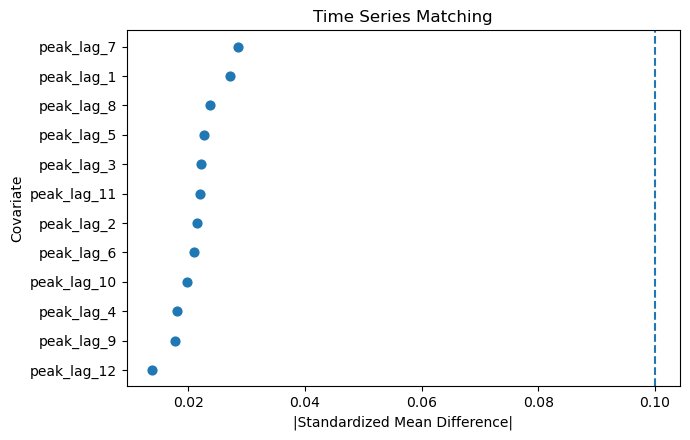

In [30]:
save_matching_results_fabric(
    res=res_ts,
    folder="Files/output/matching/time_series",
    config={
        "type": "time_series",
        "lookback_months": 12
    },
)

love_plot_from_spark(
    res_ts["balance"],
    output_path=None, 
    title="Time Series Matching"
)

StatementMeta(, 6a90ebcd-b6d1-4989-8217-117f95284648, 33, Finished, Available, Finished, False)

Running summary matching 1...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5736364
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|578944|
|2025-03-01|treated|7495  |
|2025-04-01|control|575007|
|2025-04-01|treated|4008  |
|2025-05-01|control|573401|
|2025-05-01|treated|1680  |
|2025-06-01|control|571970|
|2025-06-01|treated|1500  |
|2025-07-01|control|571260|
|2025-07-01|treated|768   |
|2025-08-01|control|570833|
|2025-08-01|treated|480   |
|2025-09-01|control|570295|
|2025-09-01|treated|588   |
|2025-10-01|control|569738|
|2025-10-01|treated|600   |
|2025-11-01|control|567999|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 478308
Standardizing by controls ...
profiles_z count = 478308
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 9831
Compu

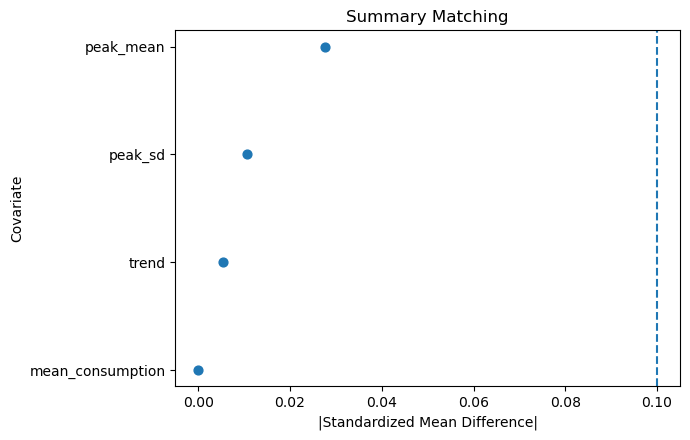

In [31]:
print("Running summary matching 1...")

res_summary_1 = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_1",
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "mean_consumption",
        "peak_sd",
        "trend"
    ],
    verbose=True,
    save_output=False
)

# res_summary_1["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_1,
    folder="Files/output/matching/summary_1",
    config={
        "type": "summary",
        "vars": ["peak_mean","mean_consumption","peak_sd","trend"]
    },
)

love_plot_from_spark(
    res_summary_1["balance"],
    output_path=None, 
    title="Summary Matching")

StatementMeta(, 6a90ebcd-b6d1-4989-8217-117f95284648, 34, Finished, Available, Finished, False)

Running summary matching 2...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5736364
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|578944|
|2025-03-01|treated|7495  |
|2025-04-01|control|575007|
|2025-04-01|treated|4008  |
|2025-05-01|control|573401|
|2025-05-01|treated|1680  |
|2025-06-01|control|571970|
|2025-06-01|treated|1500  |
|2025-07-01|control|571260|
|2025-07-01|treated|768   |
|2025-08-01|control|570833|
|2025-08-01|treated|480   |
|2025-09-01|control|570295|
|2025-09-01|treated|588   |
|2025-10-01|control|569738|
|2025-10-01|treated|600   |
|2025-11-01|control|567999|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 478308
Standardizing by controls ...
profiles_z count = 478308
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 9741
Compu

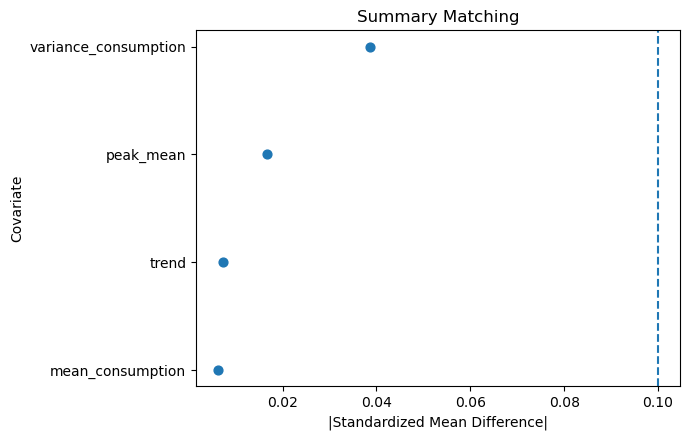

In [32]:
print("Running summary matching 2...")

res_summary_2 = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_2",
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "mean_consumption",
        "variance_consumption",
        "trend"
    ],
    verbose=True,
    save_output=False
)

# res_summary_2["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_2,
    folder="Files/output/matching/summary_2",
    config={
        "type": "summary",
        "vars": ["peak_mean","mean_consumption","variance_consumption","trend"]
    },
)

love_plot_from_spark(
    res_summary_2["balance"],
    output_path=None, 
    title="Summary Matching"
)

StatementMeta(, 6a90ebcd-b6d1-4989-8217-117f95284648, 35, Finished, Available, Finished, False)

Running summary matching 3...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5736364
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|578944|
|2025-03-01|treated|7495  |
|2025-04-01|control|575007|
|2025-04-01|treated|4008  |
|2025-05-01|control|573401|
|2025-05-01|treated|1680  |
|2025-06-01|control|571970|
|2025-06-01|treated|1500  |
|2025-07-01|control|571260|
|2025-07-01|treated|768   |
|2025-08-01|control|570833|
|2025-08-01|treated|480   |
|2025-09-01|control|570295|
|2025-09-01|treated|588   |
|2025-10-01|control|569738|
|2025-10-01|treated|600   |
|2025-11-01|control|567999|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 478308
Standardizing by controls ...
profiles_z count = 478308
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 9897
Compu

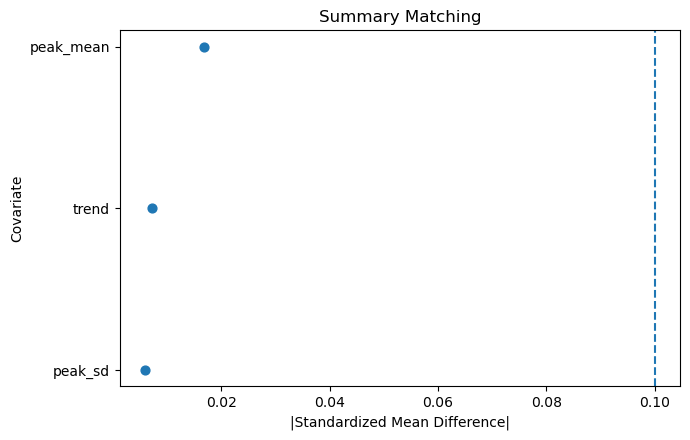

In [33]:
print("Running summary matching 3...")

res_summary_3 = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_3",
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "peak_sd",
        "trend"
    ],
    verbose=True,
    save_output=False
)

# res_summary_3["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_3,
    folder="Files/output/matching/summary_3",
    config={
        "type": "summary",
        "vars": ["peak_mean","peak_sd","trend"]
    },
)

love_plot_from_spark(
    res_summary_3["balance"],
    output_path=None, 
    title="Summary Matching"
)

StatementMeta(, 6a90ebcd-b6d1-4989-8217-117f95284648, 36, Finished, Available, Finished, False)

Running seasonal summary matching...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 4776229
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|481733|
|2025-03-01|treated|6237  |
|2025-04-01|control|478983|
|2025-04-01|treated|3340  |
|2025-05-01|control|477583|
|2025-05-01|treated|1400  |
|2025-06-01|control|476333|
|2025-06-01|treated|1250  |
|2025-07-01|control|475693|
|2025-07-01|treated|640   |
|2025-08-01|control|475293|
|2025-08-01|treated|400   |
|2025-09-01|control|474803|
|2025-09-01|treated|490   |
|2025-10-01|control|474303|
|2025-10-01|treated|500   |
|2025-11-01|control|472839|
|2025-11-01|treated|1464  |
|2025-12-01|control|471735|
|2025-12-01|treated|1210  |
+----------+-------+------+

Building summary profiles ...
profiles count = 478159
Standardizing by controls ...
profiles_z count = 478159
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 992

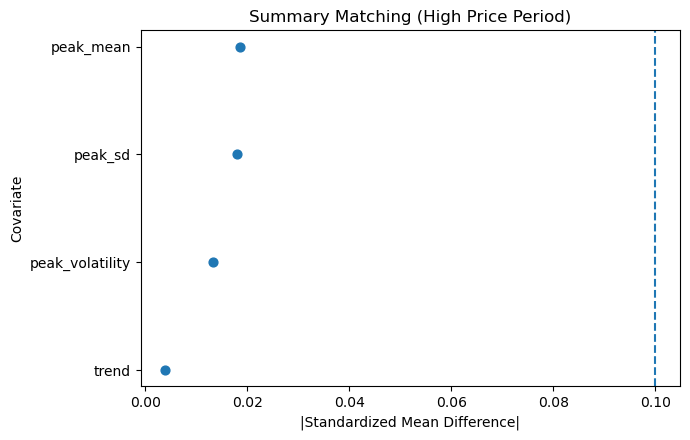

In [34]:
print("Running seasonal summary matching...")

res_summary_season = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_season",
    lookback_months=24,
    match_months=[1,2,3,11,12],
    summary_vars=[
        "peak_mean",
        "peak_sd",
        "peak_volatility",
        "trend"
    ],
    verbose=True,
    save_output=False
)

# res_summary_season["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_season,
    folder="Files/output/matching/summary_season",
    config={
        "type": "summary_season",
        "match_months": [1,2,3,11,12]
    },
)

love_plot_from_spark(
    res_summary_season["balance"],
    output_path=None, 
    title="Summary Matching (High Price Period)"
)

StatementMeta(, 9a66f72a-b221-4de8-b1b5-d66c666ad610, 9, Finished, Available, Finished, False)

Running calendar matching...
risk_rows: 4776229
Saving parquet to Files/output/matching/calendar ...
✅ Save completed


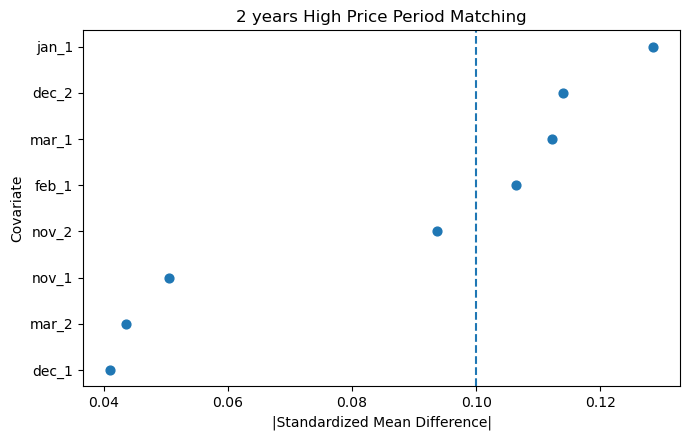

In [7]:
print("Running calendar matching...")

res_calendar = run_calendar_matching_aligned(
    sdf=month_result_spark,
    output_folder="Files/output/matching/calendar",
    lookback_years=2,
    match_months=[1,2,3,11,12],
    verbose=True,
    save_output=False
)

# res_calendar["balance"].show(5)

save_matching_results_fabric(
    res=res_calendar,
    folder="Files/output/matching/calendar",
    config={
        "type": "calendar",
        "match_months": [1,2,3,11,12]
    },
)

love_plot_from_spark(
    res_calendar["balance"],
    output_path=None, 
    title="2 years High Price Period Matching"
)

In [11]:
display(res_calendar["balance"])

StatementMeta(, 9a66f72a-b221-4de8-b1b5-d66c666ad610, 13, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 20668edf-76ae-4d0f-97b6-d61a52d090d7)